# Neural Network Decision Boundary Visualization (Keras)

This notebook visualizes how neural networks learn decision boundaries.

We compare:

- Shallow neural networks
- Deep neural networks

---

## Objective

Understand how depth increases model expressiveness and enables learning complex patterns.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

I0000 00:00:1774349430.501873    3628 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774349447.297680    3628 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774349459.171537    3628 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


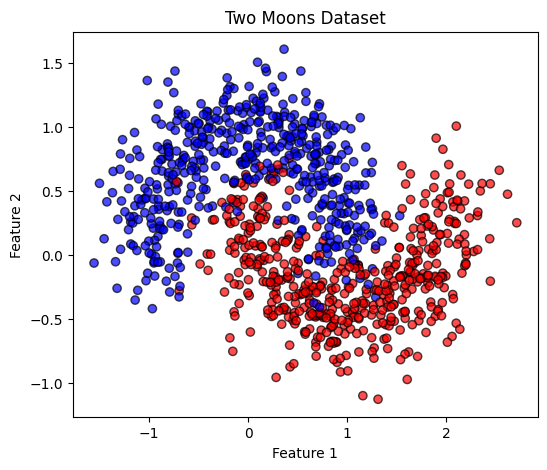

In [3]:
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", alpha=0.7)

plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):

    x0, x1 = np.meshgrid(
        np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
        np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
    )

    X_grid = np.c_[x0.ravel(), x1.ravel()]

    y_pred = model.predict(X_grid)
    y_pred = (y_pred > 0.5).astype(int)
    y_pred = y_pred.reshape(x0.shape)

    plt.contourf(x0, x1, y_pred, alpha=0.3, cmap="bwr")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", alpha=0.7)
    plt.title(title)

In [6]:
shallow_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(5, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

shallow_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

shallow_model.fit(X_train, y_train, epochs=50, verbose=0)

E0000 00:00:1774351178.210506    3628 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


2813/2813 ━━━━━━━━━━━━━━━━━━━━ 2s 607us/step


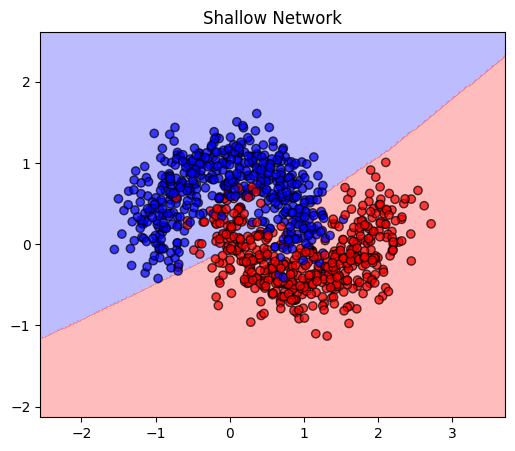

In [7]:
plt.figure(figsize=(6,5))
plot_decision_boundary(shallow_model, X, y, "Shallow Network")
plt.show()

In [8]:
deep_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

deep_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

deep_model.fit(X_train, y_train, epochs=50, verbose=0)

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 2s 611us/step


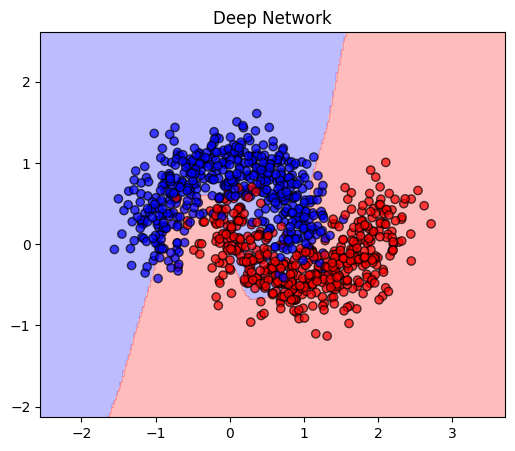

In [9]:
plt.figure(figsize=(6,5))
plot_decision_boundary(deep_model, X, y, "Deep Network")
plt.show()

## Interpretation

### Shallow Network

- Limited capacity
- Produces simpler decision boundaries
- Struggles with complex patterns

---

### Deep Network

- Learns hierarchical representations
- Produces complex nonlinear boundaries
- Better fits the structure of the data

---

## Key Insight

Depth enables neural networks to learn complex functions efficiently by composing multiple nonlinear transformations.